## USING THE FULL POWER OF THE CPU

In [2]:
using LinearAlgebra
println("Active Julia Threads: $(Threads.nthreads()) / $(Sys.CPU_THREADS)") 
BLAS.set_num_threads(Sys.CPU_THREADS)
println("Active Julia Threads: $(Threads.nthreads()) / $(Sys.CPU_THREADS)")
println("BLAS Threads: $(BLAS.get_num_threads())")

Active Julia Threads: 28 / 28
Active Julia Threads: 28 / 28
BLAS Threads: 28


## IMPORTING ALL THE IMPORTANT LIBRARY

In [3]:
using DataFrames, DifferentialEquations, OrdinaryDiffEq, Plots, CSV, Random, Lux, Optimization
using OptimizationOptimisers            
using OptimizationOptimJL: BFGS,LBFGS 
using Zygote, ComponentArrays, SciMLSensitivity, JLD2, StaticArrays, ForwardDiff
using Plots
using JLD2 , CSV

## LOADING THE DATA

In [4]:
data_loaded = CSV.read("C:/Ude_HH_model/ude_models/noisy_data.csv", DataFrame)

Row,Time,V,n,m,h
,Float64,Float64,Float64,Float64,Float64
1,0.0,-63.8175,0.304739,0.0410641,0.606856
2,0.01,-66.2215,0.317815,0.0433308,0.603907
3,0.02,-66.1148,0.316591,0.0695857,0.599555
4,0.03,-65.8069,0.312068,0.0540586,0.602316
5,0.04,-65.6637,0.316107,0.0668265,0.595131
6,0.05,-64.6233,0.316842,0.0568176,0.595027
7,0.06,-65.7883,0.316379,0.0414605,0.604426
8,0.07,-63.3764,0.327422,0.0511976,0.598935
9,0.08,-62.0713,0.314563,0.0513079,0.602126


# DEFINIG ALL THE CONSTANTS

In [5]:
# all constants
true_n = Float32.(data_loaded[!, "n"])
true_V = Float32.(data_loaded[!, "V"])

true_m = Float32.(data_loaded[!, "m"])
true_h = Float32.(data_loaded[!, "h"])
t_steps = Float32.(data_loaded[!, "Time"])
# all constants
const g_na = 120.0f0
const g_k = 36.0f0
const g_l = 0.3f0
const c_m = 1.0f0
const I_ext = 10.0f0
const E_na = 50.0f0
const E_k = -77.0f0
const E_l = -54.4f0
const u_0 = Float32[-65.0f0, 0.05f0, 0.6f0, 0.317f0]


4-element Vector{Float32}:
 -65.0
   0.05
   0.6
   0.317

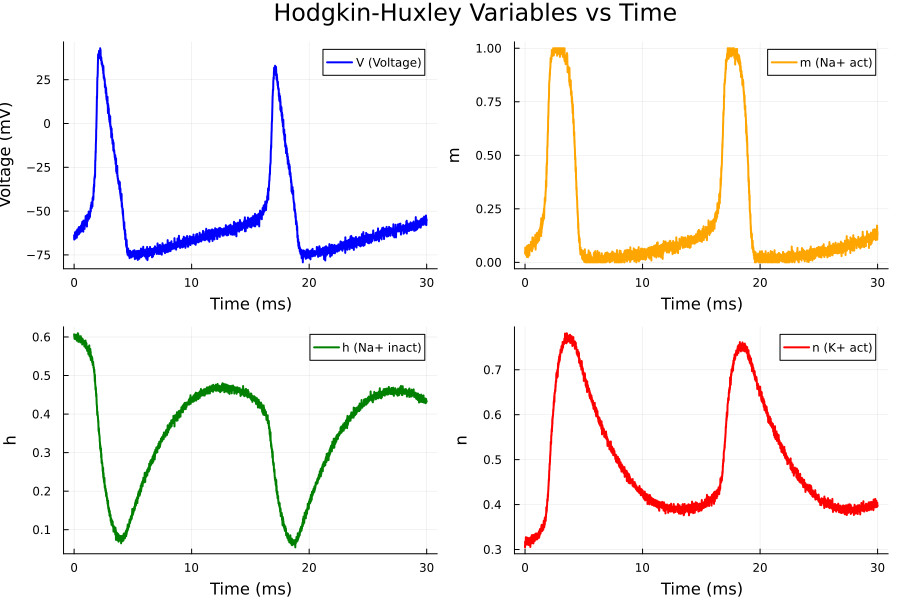

In [6]:
using Plots


p1 = plot(t_steps, true_V, label="V (Voltage)", xlabel="Time (ms)", ylabel="Voltage (mV)", lw=2, color=:blue)
p2 = plot(t_steps, true_m, label="m (Na+ act)",  xlabel="Time (ms)", ylabel="m",            lw=2, color=:orange)
p3 = plot(t_steps, true_h, label="h (Na+ inact)", xlabel="Time (ms)", ylabel="h",           lw=2, color=:green)
p4 = plot(t_steps, true_n, label="n (K+ act)",   xlabel="Time (ms)", ylabel="n",            lw=2, color=:red)

plot(p1, p2, p3, p4, layout=(2, 2), size=(900, 600), plot_title="Hodgkin-Huxley Variables vs Time")


## DEFINIGING ALL THE RATE CONSTANTS

In [7]:

alpha_n(V) = abs(V + 55.0f0) < 1.0f-6 ? 0.1f0 : 0.01f0 * (V + 55.0f0) / (1.0f0 - exp(-(V + 55.0f0) / 10.0f0))
beta_n(V) = 0.125f0 * exp(-(V + 65.0f0) / 80.0f0)

beta_n (generic function with 1 method)

In [8]:

alpha_m(V) = abs(V + 40.0f0) < 1.0f-6 ? 1.0f0 : 0.1f0 * (V + 40.0f0) / (1.0f0 - exp(-(V + 40.0f0) / 10.0f0))
beta_m(V) = 4.0f0 * exp(-(V + 65.0f0) / 18.0f0)

beta_m (generic function with 1 method)

In [9]:

alpha_h(V) = 0.07f0 * exp(-(V + 65.0f0) / 20.0f0)
beta_h(V) = 1.0f0 / (1.0f0 + exp(-(V + 35.0f0) / 10.0f0))

beta_h (generic function with 1 method)

## DEFINGING THE RANDOM SEED 

In [10]:
rng = Random.seed!(42)


TaskLocalRNG()

## DEFINIG THE NETWORK STRUCTURE

In [11]:
nn = Chain(Dense(1 => 32),
    Dense(32 => 32, tanh),
    Dense(32 => 1, sigmoid))
ps, st = Lux.setup(rng, nn)
display(nn)

Chain(
    layer_1 = Dense(1 => 32),                     # 64 parameters
    layer_2 = Dense(32 => 32, tanh),              # 1_056 parameters
    layer_3 = Dense(32 => 1, σ),                  # 33 parameters
)         # Total: 1_153 parameters,
          #        plus 0 states.

## DEFINING THE UDE FOR HH 4D MODEL TO TRANING THE ABOVE NETWORK

In [12]:
function ude_hh(u, ps, t)
    V, m, h, n = u
    pred_n, _ = nn(SA[n], ps, st)


    dV = (I_ext - g_na * m^3 * h * (V - E_na) - g_k * pred_n[1] * (V - E_k) - g_l * (V - E_l)) / c_m
    dm = alpha_m(V) * (1.0f0 - m) - beta_m(V) * m
    dh = alpha_h(V) * (1.0f0 - h) - beta_h(V) * h
    dn = alpha_n(V) * (1.0f0 - n) - beta_n(V) * n

    return @SVector [dV, dm, dh, dn]
end


ude_hh (generic function with 1 method)

## SETTING THE INITIAL VALUES OF UDE EQUATION 

In [13]:
# Define with StaticArray initial conditions:
const u_0 = @SVector [-65.0f0, 0.05f0, 0.6f0, 0.317f0]
tspan = (0.0f0, 30.0f0)
prob = ODEProblem(ude_hh, u_0, tspan, ps)


ODEProblem with uType SVector{4, Float32} and tType Float32. In-place: false
Non-trivial mass matrix: false
timespan: (0.0f0, 30.0f0)
u0: 4-element SVector{4, Float32} with indices SOneTo(4):
 -65.0
   0.05
   0.6
   0.317

## DEFINING THE LOSS FUNCTION


In [14]:
function loss_function(ps, p)
    prob = ODEProblem(ude_hh, u_0, tspan, ps)
    sol = solve(
        prob,
        Rosenbrock23(),
        reltol=1e-4,
        abstol=1e-4,
        saveat=t_steps,
        sensealg=ForwardDiffSensitivity(),
        force_dtmin=true
    )

    pred_V = sol[1, :]
    return sum(abs2, pred_V - true_V) / length(true_V)
end

loss_function (generic function with 1 method)

Optimization

## CREATING AN CALLBACK FUNTION TO STORE AND SHOW LOGS

In [15]:
const loss_history = []
const iter_history = []
function callback(state, l)

    push!(loss_history, Float32(l))
    push!(iter_history, state.iter)
    if state.iter % 10 == 0
        println("current iteration = $(state.iter)  | current_loss = $(l)")
        if state.iter % 100 == 0
            jldsave("C:/Ude_HH_model/ude_models/leaning_parameter.jld2"; p=state.u)
        end
    end
    return false
end

callback (generic function with 1 method)

## DEFINIG THE OPTIMIZATION  FUNCTION FOR OUR UDE MODEL

In [16]:
opt = OptimizationFunction(loss_function, AutoForwardDiff())

net = ComponentArray(ps)
opt_prob = OptimizationProblem(opt, net)


OptimizationProblem. In-place: true
u0: ComponentVector{Float32}(layer_1 = (weight = Float32[-0.15767582; -1.1307708; … ; 0.19089252; 0.42486224;;], bias = Float32[0.6402823, -0.15548313, 0.3585751, 0.47565484, -0.83354366, -0.7983309, -0.9632733, -0.35786855, 0.1624806, 0.93903005  …  0.86745214, 0.8148211, 0.38635254, -0.62182, -0.18979192, -0.6013012, -0.8030517, 0.56790996, -0.28980362, 0.96977556]), layer_2 = (weight = Float32[0.37709013 -0.4490932 … -0.3449148 -0.36564463; 0.054253716 0.49733526 … 0.35948935 0.24132304; … ; 0.49617618 0.08238792 … 0.18305631 -0.1491749; -0.021193195 -0.16762535 … -0.43130484 0.3783914], bias = Float32[0.03878094, -0.007602322, -0.11970364, -0.098564304, -0.025683658, -0.039688274, -0.12524073, 0.012478712, -0.054133095, 0.12872824  …  0.040868536, 0.09221246, -0.08388274, 0.08786137, -0.1030199, -0.08795758, 0.07973033, 0.059021942, 0.066383034, 0.067760795]), layer_3 = (weight = Float32[-0.29468712 -0.103986636 … -0.19075362 -0.13402101], bias =

## PREPARING FOR TRAINING THE UDE MODEL 

### PHASE 1 : ADAM( O.0025)  ---> 600

In [17]:

println("--- Phase 1: Adam(0.0025) [600 maxiters] ---")
res1 = solve(opt_prob, Adam(0.0025), callback=callback, maxiters=600)


--- Phase 1: Adam(0.0025) [600 maxiters] ---
current iteration = 10  | current_loss = 897.0963
current iteration = 20  | current_loss = 747.60205
current iteration = 30  | current_loss = 813.3696
current iteration = 40  | current_loss = 829.1249
current iteration = 50  | current_loss = 825.9287
current iteration = 60  | current_loss = 814.55963
current iteration = 70  | current_loss = 799.0768
current iteration = 80  | current_loss = 781.04193
current iteration = 90  | current_loss = 761.01373
current iteration = 100  | current_loss = 739.07117
current iteration = 110  | current_loss = 715.13104
current iteration = 120  | current_loss = 698.9294
current iteration = 130  | current_loss = 1981.1617
current iteration = 140  | current_loss = 2139.8867
current iteration = 150  | current_loss = 1795.6426
current iteration = 160  | current_loss = 1574.5648
current iteration = 170  | current_loss = 1540.6967
current iteration = 180  | current_loss = 1413.6785
current iteration = 190  | current

retcode: Default
u: ComponentVector{Float32}(layer_1 = (weight = Float32[-0.116357744; -1.2934442; … ; 0.21004811; 0.307054;;], bias = Float32[0.699944, -0.26355094, 0.3410774, 0.513909, -0.8533401, -0.84964126, -1.0151813, -0.32986465, 0.14313106, 1.0875347  …  0.8729264, 0.7534271, 0.42235437, -0.6243356, -0.22856499, -0.58213484, -0.8384446, 0.57277596, -0.24664712, 0.89170235]), layer_2 = (weight = Float32[0.44993296 -0.52565825 … -0.44088343 -0.2910595; 0.12596835 0.42236432 … 0.2602116 0.31515327; … ; 0.54868656 0.05273771 … 0.057466075 -0.100454204; 0.03392558 -0.19072546 … -0.5614464 0.4289391], bias = Float32[0.11437689, 0.06753959, -0.049388994, -0.037930317, -0.08184601, -0.10819567, -0.18013978, 0.071118586, -0.093033716, 0.16914831  …  0.039125085, 0.020732362, -0.14996274, 0.13700008, -0.17363, -0.14703204, 0.009417287, -0.008673528, 0.11678652, 0.121833414]), layer_3 = (weight = Float32[-0.3288965 -0.16105339 … -0.25986665 -0.19228442], bias = Float32[0.050690167]))

In [ ]:

println("--- Phase 2:  BFGS ()   [200 maxiters] ---")

opt_prob2 = remake(opt_prob, u0=res1.u)
res2 = solve(opt_prob2, BFGS(), callback=callback, maxiters=200)

## SAVING THE PARAMETER TO FILE

In [ ]:
# Save final parameters
jldsave("C:/Ude_HH_model/ude_models/leaning_parameter4.jld2"; p=res3.u)
println("Training completed and parameters saved to C:/Ude_HH_model/ude_models/leaning_parameter2.jld2")

--- Phase 4: lBFGS [200 maxiters] ---


retcode: Success
u: ComponentVector{Float32}(layer_1 = (weight = Float32[-0.6080422; -0.74058294; … ; -0.98354095; -1.592633;;], bias = Float32[-0.13480759, 0.27049735, 0.38293442, -0.54462796, -0.74287164, 0.73560584, -0.7931202, -0.16193067, -0.27777836, -0.628612  …  -0.30235395, -0.53258324, -0.4553165, 0.7019243, 0.76495266, -0.7871774, 0.41377634, -0.2316377, -0.8057268, 0.064287886]), layer_2 = (weight = Float32[0.47606942 -0.7872422 … 0.11856469 0.29270783; -0.123785816 -0.7941496 … 0.26713264 0.20407088; … ; -0.32579085 -0.451226 … 0.1688878 -0.22592618; -0.45250726 0.6327509 … 0.34904402 0.3341336], bias = Float32[-0.29615116, -0.18444972, -0.17564376, -0.027623894, -0.024281226, 0.24797465, -0.41997963, -0.046875242, -0.023758508, -0.029667214  …  0.020366924, 0.04825906, -0.102429844, -0.14924613, -0.052348744, 0.06175465, 0.14636882, 0.12266915, -0.16924112, -0.030196376]), layer_3 = (weight = Float32[0.2222771 0.2324972 … 0.21288674 -0.25893962], bias = Float32[0.06169117

In [ ]:
plot(iter_history,loss_history)